# RL Network-Markowitz Portfolio Optimization
### Thesis-Ready Version (Fixed) — Multi-Seed SAC + Ablation Study + XAI Analysis

**Ringkasan perbaikan dari versi sebelumnya:**
- Duplikasi definisi fungsi dihapus (tiap fungsi hanya didefinisikan sekali)
- Cache key diubah ke tuple `('train', i)` / `('test', i)` agar tidak collision
- `compute_market_features`: parameter `port_val` yang tidak dipakai dihapus
- `_solve_weights`: menambahkan `warnings.warn` saat fallback ke equal-weight
- `get_obs_dim` & `build_observation`: konsisten — raise `ValueError` jika keduanya False
- `AblationPortfolioEnv`: `_rew_stats` di-reset tiap `reset()` (bukan akumulasi lintas episode)
- `AblationPortfolioEnv`: parameter `split='train'/'test'` menggantikan `data_start_offset` integer
- `run_wilcoxon_tests` sekarang dipanggil di Final Analysis dan hasilnya ditampilkan
- Label `Features` di dashboard diperbaiki: `Network(2) + Market(7)` (bukan 5+4)
- `FEATURE_NAMES` dikelompokkan dengan komentar agar sesuai implementasi
- `plot_shap_analysis`: background & explain sample diperbesar; skip jika model None
- Judul notebook disesuaikan: CVaR adalah metrik evaluasi, bukan reward RL


## 1. Imports & Global Settings

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
import seaborn as sns
import shap
import torch
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import SAC
from stable_baselines3.common.callbacks import BaseCallback
from tqdm.notebook import tqdm
from scipy import stats
from scipy.optimize import minimize
from IPython.display import display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

# ================================================================
# GLOBAL SETTINGS
# ================================================================
SEEDS         = [42, 123, 77]
TRAIN_STEPS   = 10000
FORCE_RETRAIN = True    # Set False jika model sudah ada
SET_WINDOW    = 30
SET_REBALANCE = 7
REWARD_WINDOW = 20
CVAR_LEVEL    = 0.95    # CVaR digunakan sebagai metrik evaluasi, bukan reward
STAT_ALPHA    = 0.05
SAVE_IMAGES   = False

ABLATION_CONFIGS = {
    'E2_Sharpe'          : {'use_network': True,  'use_market': True,  'reward_type': 'sharpe'},
    'E2_Sortino'         : {'use_network': True,  'use_market': True,  'reward_type': 'sortino'},
    'E2_Calmar'          : {'use_network': True,  'use_market': True,  'reward_type': 'calmar'},
    'E2_Ulcer'           : {'use_network': True,  'use_market': True,  'reward_type': 'ulcer'},
    'E2_Ensemble_Avg'    : {'use_network': True,  'use_market': True,  'is_ensemble': True},
    'Comp_Static_Gamma0' : {'use_network': True,  'use_market': False, 'static_gamma': 0.0},
    'Comp_Static_Gamma1' : {'use_network': True,  'use_market': False, 'static_gamma': 1.0},
    'Comp_Static_Gamma2' : {'use_network': True,  'use_market': False, 'static_gamma': 2.0},
}

EVAL_METRICS = ['Sharpe Ratio', 'Sortino Ratio', 'Calmar Ratio', 'Ulcer Index']

SCRIPT_DIR = os.getcwd()
OUTPUT_DIR = os.path.join(SCRIPT_DIR, 'ablation_results_thesis')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('Environment initialized.')
print(f'Output dir: {OUTPUT_DIR}')


Environment initialized.
Output dir: g:\My Drive\00_Kuliah\Thesis\sharpenThesis_dpInsya\guidici_reexperiment_clean\ablation_results_thesis


## 2. Data Loading

In [2]:
file_data = 'crypto_data_real.xlsx'

def load_and_split(filename, train_split=0.7):
    df = pd.read_excel(filename, sheet_name='Returns', index_col=0)
    df.index = pd.to_datetime(df.index)
    assets = list(df.columns)
    if 'USDT' in assets:
        assets.remove('USDT')
    assets.sort()
    df = df[assets]
    split_idx = int(len(df) * train_split)
    return df.iloc[:split_idx], df.iloc[split_idx:], assets

ret_train, ret_test, assets = load_and_split(file_data)

print(f'Assets  : {len(assets)} — {assets}')
print(f'Training: {ret_train.index[0].date()} to {ret_train.index[-1].date()} ({len(ret_train)} rows)')
print(f'Testing : {ret_test.index[0].date()} to {ret_test.index[-1].date()} ({len(ret_test)} rows)')


Assets  : 9 — ['BCH', 'BNB', 'BTC', 'EOS', 'ETH', 'LTC', 'TRX', 'XLM', 'XRP']
Training: 2017-09-15 to 2019-03-02 (534 rows)
Testing : 2019-03-03 to 2019-10-17 (229 rows)


## 3. Portfolio Optimization Logic

In [3]:
def apply_rmt_filter(returns_window):
    """Random Matrix Theory denoising filter pada correlation matrix."""
    T, N = returns_window.shape
    corr_mat = returns_window.corr().fillna(0).values
    eigenvalues, eigenvectors = np.linalg.eigh(corr_mat)
    Q = T / N
    lambda_max = (1 + np.sqrt(1 / Q)) ** 2
    n_signal = np.sum(eigenvalues >= lambda_max)
    if n_signal == 0:
        eigenvalues[:-1] = 0
    else:
        eigenvalues[eigenvalues < lambda_max] = 0
    corr_denoised = eigenvectors @ np.diag(eigenvalues) @ eigenvectors.T
    np.fill_diagonal(corr_denoised, 1)
    return corr_denoised


def _solve_weights(cov_f, cent_vec, mu, gamma, n_assets):
    """
    Minimisasi: w^T * cov_f * w + gamma * cent_vec^T * w
    subject to: sum(w)=1, long-only, dan opsional return constraint.
    FIX: menambahkan warning eksplisit saat fallback ke equal-weight.
    """
    fun    = lambda w: w.T @ cov_f @ w + gamma * np.sum(cent_vec * w)
    w0     = np.ones(n_assets) / n_assets
    bounds = tuple((0.0, 1.0) for _ in range(n_assets))
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    if res2.success:
        return res2.x
    # FIX: warn secara eksplisit — jangan diam-diam fallback
    warnings.warn(
        f'Optimization failed (gamma={gamma:.3f}). Falling back to equal-weight.',
        RuntimeWarning, stacklevel=2
    )
    return w0


def _build_mst_centrality(N, corr_f):
    """Bangun MST dari RMT-denoised correlation matrix, hitung eigenvector centrality."""
    dist_mat = np.sqrt(np.maximum(0, 2 * (1 - corr_f)))
    G_full   = nx.from_numpy_array(dist_mat)
    mst      = nx.minimum_spanning_tree(G_full)
    try:
        centrality = nx.eigenvector_centrality(mst, max_iter=300)
        cent_vec   = np.array([centrality[i] for i in range(N)])
    except Exception:
        cent_vec = np.array(list(nx.degree_centrality(mst).values()))
    return mst, cent_vec


def fast_centrality_weights(cov_f, cent_vec, mu, gamma):
    return _solve_weights(cov_f, cent_vec, mu, gamma, len(mu))


def compute_classic_mv_weights(returns_window):
    """Mean-Variance klasik Markowitz sebagai baseline."""
    T, N = returns_window.shape
    mu   = returns_window.mean().values
    cov  = np.cov(returns_window.values.T) + np.eye(N) * 1e-8
    w0     = np.ones(N) / N
    bounds = tuple((0.0, 1.0) for _ in range(N))
    fun    = lambda w: w @ cov @ w
    cons_with_ret = (
        {'type': 'eq',   'fun': lambda w: np.sum(w) - 1},
        {'type': 'ineq', 'fun': lambda w: np.dot(w, mu) - np.mean(mu)},
    )
    cons_no_ret = ({'type': 'eq', 'fun': lambda w: np.sum(w) - 1},)
    res = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_with_ret)
    if res.success:
        return res.x
    res2 = minimize(fun, w0, method='SLSQP', bounds=bounds, constraints=cons_no_ret)
    return res2.x if res2.success else w0


## 4. Metrics & Helpers

In [4]:
def _compute_drawdown(arr):
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd   = (cumulative - peak) / peak
    return dd, cumulative


def calculate_annualized_return(ret_series, periods_per_year=252):
    arr = np.array(ret_series)
    n   = len(arr)
    if n == 0:
        return np.nan
    total = (1 + arr).prod()
    if total <= 0:
        return np.nan
    return total ** (periods_per_year / n) - 1


def calculate_sharpe_ratio(ret_series, periods_per_year=252):
    arr     = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    return ann_ret / ann_vol if ann_vol > 0 else 0.0


def calculate_sortino_ratio(ret_series, periods_per_year=252, mar=0.0):
    arr      = np.array(ret_series)
    ann_ret  = calculate_annualized_return(arr, periods_per_year)
    downside = arr[arr < mar]
    if len(downside) == 0:
        return 0.0
    downside_dev = np.std(downside) * np.sqrt(periods_per_year)
    return ann_ret / downside_dev if downside_dev > 0 else 0.0


def calculate_calmar_ratio(ret_series, periods_per_year=252):
    arr     = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    dd, _   = _compute_drawdown(arr)
    max_dd  = dd.min()
    return ann_ret / abs(max_dd) if abs(max_dd) > 1e-8 else 0.0


def calculate_cvar(ret_series, confidence=0.95):
    """Conditional Value-at-Risk (CVaR / Expected Shortfall).
    Digunakan sebagai metrik EVALUASI, bukan sebagai fungsi reward RL."""
    arr = np.array(ret_series)
    if len(arr) == 0:
        return 0.0
    var         = np.percentile(arr, (1 - confidence) * 100)
    tail_losses = arr[arr <= var]
    return float(-np.mean(tail_losses)) if len(tail_losses) > 0 else 0.0


def calculate_ulcer_index(ret_series):
    arr = np.array(ret_series)
    if len(arr) == 0:
        return 0.0
    cumulative = (1 + arr).cumprod()
    peak = np.maximum.accumulate(cumulative)
    dd   = (cumulative - peak) / peak
    return float(np.sqrt(np.mean(dd ** 2)))


def calculate_all_metrics(ret_series, cvar_level=0.95, periods_per_year=252):
    arr     = np.array(ret_series)
    ann_ret = calculate_annualized_return(arr, periods_per_year)
    ann_vol = arr.std() * np.sqrt(periods_per_year)
    dd, _   = _compute_drawdown(arr)
    return {
        'Sharpe Ratio'    : calculate_sharpe_ratio(arr, periods_per_year),
        'Sortino Ratio'   : calculate_sortino_ratio(arr, periods_per_year),
        'Calmar Ratio'    : calculate_calmar_ratio(arr, periods_per_year),
        'CVaR (95%)'      : calculate_cvar(arr, cvar_level),
        'Total Return'    : (1 + arr).prod() - 1,
        'Ann. Return'     : ann_ret,
        'Ann. Volatility' : ann_vol,
        'Max Drawdown'    : dd.min(),
        'Ulcer Index'     : calculate_ulcer_index(arr),
    }


## 5. Visualization Helpers

In [5]:
ABLATION_COLORS = {
    'E2_Sharpe'          : '#FF9800',
    'E2_Sortino'         : '#9C27B0',
    'E2_Calmar'          : '#2196F3',
    'E2_Ulcer'           : '#F44336',
    'E2_Ensemble_Avg'    : '#00BCD4',
    'Comp_Static_Gamma0' : '#9E9E9E',
    'Comp_Static_Gamma1' : '#795548',
    'Comp_Static_Gamma2' : '#607D8B',
    'Classic-MV'         : '#3F51B5',
}

DISPLAY_NAMES = {
    'E2_Sharpe'          : 'E2-Sharpe',
    'E2_Sortino'         : 'E2-Sortino',
    'E2_Calmar'          : 'E2-Calmar',
    'E2_Ulcer'           : 'E2-Ulcer',
    'E2_Ensemble_Avg'    : 'E2-Ensemble',
    'Comp_Static_Gamma0' : 'gamma=0 (Static)',
    'Comp_Static_Gamma1' : 'gamma=1 (Static)',
    'Comp_Static_Gamma2' : 'gamma=2 (Static)',
    'Classic-MV'         : 'Classic-MV',
}

# FIX: 2 network + 7 market = 9 total, sesuai implementasi
FEATURE_NAMES = [
    'MST.Dist x0.1', 'Spectral.Gap',           # network (2)
    'VolShort x100', 'VolLong x100', 'Vol.Ratio',  # market: volatility (3)
    'Mom5d x100', 'Mom20d x100', 'MomCross x100', 'Pct.Uptrend',  # market: momentum (4)
]


def get_display_name(exp_id):
    return DISPLAY_NAMES.get(exp_id, exp_id)


class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards        = []
        self.current_episode_reward = 0.0

    def _on_step(self) -> bool:
        self.current_episode_reward += self.locals['rewards'][0]
        if self.locals['dones'][0]:
            self.episode_rewards.append(self.current_episode_reward)
            self.current_episode_reward = 0.0
        return True


def plot_learning_curves(history_dict):
    plt.figure(figsize=(10, 4))
    for seed, rewards in history_dict.items():
        if len(rewards) == 0:
            continue
        smoothed = pd.Series(rewards).rolling(window=max(1, len(rewards) // 10)).mean()
        plt.plot(smoothed, label=f'seed={seed}', alpha=0.8)
    plt.title(f'SAC Learning Curves - Steps: {TRAIN_STEPS}', fontsize=12, fontweight='bold')
    plt.xlabel('Episode')
    plt.ylabel('Smoothed Episode Reward')
    plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
    plt.legend(fontsize=8)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, 'learning_curves.png'), dpi=150)
    plt.show()
    plt.close()


## 6. Dashboard & Statistical Analysis

In [6]:
def run_wilcoxon_tests(results_dict, baseline_id='Classic-MV'):
    """
    Wilcoxon signed-rank test: tiap eksperimen vs baseline.
    Mengembalikan dict {exp_id: p_value}.
    FIX: mengembalikan dict (bukan string), index disejajarkan sebelum test.
    """
    if baseline_id not in results_dict:
        print('Baseline not found in results.')
        return {}
    baseline_rets = results_dict[baseline_id].mean(axis=1)
    pvalues = {}
    for exp_id, rets_df in results_dict.items():
        if exp_id == baseline_id:
            continue
        exp_rets   = rets_df.mean(axis=1)
        common_idx = baseline_rets.index.intersection(exp_rets.index)
        try:
            _, p = stats.wilcoxon(exp_rets.loc[common_idx], baseline_rets.loc[common_idx])
            pvalues[exp_id] = p
        except Exception:
            pvalues[exp_id] = np.nan
    return pvalues


def generate_dashboard(results_dict, title_prefix, period_name, filename_base):
    exp_ids      = list(results_dict.keys())
    metrics_list = []

    for exp_id in exp_ids:
        rets_df = results_dict[exp_id]
        m_seeds = [calculate_all_metrics(rets_df[s], CVAR_LEVEL) for s in rets_df.columns]
        # FIX: label Features sesuai implementasi (2 network + 7 market)
        feat_label = 'Network(2) + Market(7)' if str(exp_id).startswith('E2') else 'Static / Baseline'
        res = {
            'Experiment': exp_id,
            'Features'  : feat_label,
            'Obs Dim'   : get_obs_dim(ABLATION_CONFIGS[exp_id]) if exp_id in ABLATION_CONFIGS else 0,
        }
        for m in EVAL_METRICS:
            vals = [ms[m] for ms in m_seeds]
            res[f'{m} Mean'] = np.mean(vals)
            res[f'{m} Std']  = np.std(vals)
        metrics_list.append(res)

    df_metrics = pd.DataFrame(metrics_list).sort_values(by='Sharpe Ratio Mean', ascending=False)

    # --- Plot 1: Table + Bar Charts ---
    fig1 = plt.figure(figsize=(16, 10), facecolor='white')
    gs1  = gridspec.GridSpec(2, 4, height_ratios=[1.2, 1.0])
    fig1.suptitle(
        f'{title_prefix} - Metrics Comparison\nSteps: {TRAIN_STEPS}',
        fontsize=14, fontweight='bold', y=0.98
    )

    ax_table = fig1.add_subplot(gs1[0, :])
    ax_table.axis('off')
    columns    = ['Experiment', 'Features', 'Obs Dim',
                  'Sharpe (up)', 'Sortino (up)', 'Calmar (up)', 'Ulcer (down)', 'Rank']
    table_data = []
    for rank, (_, row) in enumerate(df_metrics.iterrows(), 1):
        table_data.append([
            row['Experiment'], row['Features'], row['Obs Dim'],
            f"{row['Sharpe Ratio Mean']:.3f}+/-{row['Sharpe Ratio Std']:.3f}",
            f"{row['Sortino Ratio Mean']:.3f}+/-{row['Sortino Ratio Std']:.3f}",
            f"{row['Calmar Ratio Mean']:.3f}+/-{row['Calmar Ratio Std']:.3f}",
            f"{row['Ulcer Index Mean']:.4f}+/-{row['Ulcer Index Std']:.4f}",
            f'#{rank}',
        ])
    table = ax_table.table(cellText=table_data, colLabels=columns, loc='center', cellLoc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1, 2)
    ax_table.set_title('Rangkuman Metrik Performa', fontsize=11, fontweight='bold', pad=15)

    for i, m in enumerate(EVAL_METRICS):
        ax    = fig1.add_subplot(gs1[1, i])
        exps  = [row['Experiment'] for _, row in df_metrics.iterrows()]
        means = [row[f'{m} Mean']   for _, row in df_metrics.iterrows()]
        ax.bar(range(len(exps)), means,
               color=[ABLATION_COLORS.get(e, '#777777') for e in exps])
        ax.set_title(m, fontsize=10, fontweight='bold')
        ax.set_xticks(range(len(exps)))
        ax.set_xticklabels([get_display_name(e) for e in exps],
                           rotation=45, ha='right', fontsize=7)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'1_metrics_{filename_base}'), dpi=200)
    plt.show()
    plt.close()

    # --- Plot 2: Cumulative Returns ---
    plt.figure(figsize=(16, 7), facecolor='white')
    for exp_id in results_dict:
        cum = (1 + results_dict[exp_id].mean(axis=1)).cumprod()
        plt.plot(cum, label=get_display_name(exp_id),
                 color=ABLATION_COLORS.get(exp_id, '#777777'))
    plt.title(f'Cumulative Returns - {period_name} Period - Steps: {TRAIN_STEPS}',
              fontsize=14, fontweight='bold')
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.legend(fontsize=8)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'2_returns_{filename_base}'), dpi=200)
    plt.show()
    plt.close()


## 7. SHAP Interpretability Analysis

In [7]:
def plot_shap_analysis(model_paths, env, config, exp_id,
                       n_background=100, n_explain=200):
    """
    SHAP analysis untuk model SAC.
    FIX:
    - Sample dikumpulkan dari satu episode penuh (bukan loop reset 50x)
    - n_background & n_explain diperbesar untuk thesis-quality hasil
    - Lewati eksperimen jika model None
    """
    print(f'Generating SHAP analysis for {exp_id}...')
    if isinstance(model_paths, list):
        models = [SAC.load(p) for p in model_paths if p is not None]
    else:
        models = [SAC.load(model_paths)] if model_paths is not None else []

    if len(models) == 0:
        print(f'  Skipped {exp_id}: tidak ada model yang valid.')
        return

    obs_list = []
    obs, _   = env.reset()
    done     = False
    while not done:
        obs_list.append(obs.copy())
        action, _ = models[0].predict(obs, deterministic=True)
        obs, _, done, _, _ = env.step(action)

    n_total = len(obs_list)
    if n_total < n_background + 10:
        print(f'  Warning: hanya {n_total} obs tersedia untuk {exp_id}.')
        n_background = max(10, n_total // 3)
        n_explain    = min(50, n_total - n_background)

    X    = np.array(obs_list)
    feat = FEATURE_NAMES[:X.shape[1]]
    df_X = pd.DataFrame(X, columns=feat)

    def predict_action(x):
        x_t = torch.tensor(np.array(x), dtype=torch.float32)
        with torch.no_grad():
            acts = [m.policy.actor(x_t).numpy() for m in models]
        return np.mean(acts, axis=0)

    background  = df_X.iloc[:n_background]
    explain     = df_X.iloc[n_background:n_background + n_explain]
    explainer   = shap.Explainer(predict_action, background)
    shap_values = explainer(explain)

    plt.figure(figsize=(10, 6))
    shap.summary_plot(shap_values, explain, show=False)
    plt.title(f'SHAP Feature Importance - {exp_id} - Steps: {TRAIN_STEPS}',
              fontsize=12, fontweight='bold')
    if SAVE_IMAGES:
        plt.savefig(os.path.join(OUTPUT_DIR, f'shap_summary_{exp_id}.png'), dpi=150)
    plt.show()
    plt.close()


## 8. Feature Engineering & Cache

In [8]:
def compute_network_features(returns_window):
    """
    Menghasilkan 2 network features:
      [0] MST total distance * 0.1
      [1] Spectral gap (algebraic connectivity MST)
    """
    T, N  = returns_window.shape
    corr_f = apply_rmt_filter(returns_window)
    mst, cent_vec = _build_mst_centrality(N, corr_f)
    mst_dist     = sum(d['weight'] for _, _, d in mst.edges(data=True))
    spectral_gap = nx.algebraic_connectivity(mst)
    return np.array([mst_dist * 0.1, spectral_gap], dtype=np.float32), corr_f, cent_vec


def compute_market_features(returns_window):
    """
    Menghasilkan 7 market features:
      [0] VolShort x100   [1] VolLong x100   [2] Vol.Ratio
      [3] Mom5d x100      [4] Mom20d x100     [5] MomCross x100  [6] Pct.Uptrend
    FIX: parameter port_val yang tidak digunakan dihapus.
    """
    arr = returns_window.values
    T, N = arr.shape
    win5, win20 = max(1, min(5, T)), max(1, min(20, T))
    v5   = arr[-win5:].std(axis=0).mean()
    v20  = arr[-win20:].std(axis=0).mean()
    m5   = arr[-win5:].mean(axis=0).mean()
    m20  = arr[-win20:].mean(axis=0).mean()
    pct_up = float(np.mean(arr[-win5:].mean(axis=0) > arr[-win20:].mean(axis=0)))
    return np.array([
        v5 * 100, v20 * 100, v5 / (v20 + 1e-8),
        m5 * 100, m20 * 100, (m5 - m20) * 100, pct_up
    ], dtype=np.float32)


def get_obs_dim(config):
    """
    FIX: raise ValueError jika keduanya False (bukan diam-diam return 1).
    Konsisten dengan build_observation yang juga akan error dalam kasus itu.
    """
    d = 0
    if config.get('use_network', False): d += 2
    if config.get('use_market',  False): d += 7
    if d == 0:
        raise ValueError(
            f'Config {config} menghasilkan obs_dim=0. '
            'Aktifkan use_network atau use_market.'
        )
    return d


# ── Precompute Cache ──────────────────────────────────────────────────────
# FIX: key tuple ('train', i) / ('test', i) menggantikan integer offset
# agar tidak ada collision antara index train dan test.
GLOBAL_CACHE = {}

print('Precomputing training cache...')
for i in tqdm(range(SET_WINDOW, len(ret_train))):
    win     = ret_train.iloc[i - SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    std_vec = win.std().values
    GLOBAL_CACHE[('train', i)] = {
        'win'         : win,
        'corr_f'      : corr,
        'cent_vec'    : cent,
        # cov_f: RMT-denoised pseudo-covariance + regularisasi diagonal
        'cov_f'       : np.outer(std_vec, std_vec) * corr + np.eye(len(assets)) * 1e-8,
        'mu'          : win.mean().values,
        'nw_feat_full': feat,
    }

print('Precomputing testing cache...')
for i in tqdm(range(SET_WINDOW, len(ret_test))):
    win     = ret_test.iloc[i - SET_WINDOW:i]
    feat, corr, cent = compute_network_features(win)
    std_vec = win.std().values
    GLOBAL_CACHE[('test', i)] = {
        'win'         : win,
        'corr_f'      : corr,
        'cent_vec'    : cent,
        'cov_f'       : np.outer(std_vec, std_vec) * corr + np.eye(len(assets)) * 1e-8,
        'mu'          : win.mean().values,
        'nw_feat_full': feat,
    }

# Normalisasi: hanya dari data training (no data leakage ke test)
_train_feats = np.stack([
    GLOBAL_CACHE[('train', i)]['nw_feat_full']
    for i in range(SET_WINDOW, len(ret_train))
])
FEAT_MEAN = _train_feats.mean(axis=0)
FEAT_STD  = _train_feats.std(axis=0) + 1e-8

print(f'Cache siap: {len(GLOBAL_CACHE)} entries')
print(f'  FEAT_MEAN = {FEAT_MEAN}')
print(f'  FEAT_STD  = {FEAT_STD}')


def build_observation(win, config, nw_feat_raw=None, corr_f=None):
    if nw_feat_raw is None:
        nw_feat_raw, corr_f, _ = compute_network_features(win)
    obs = []
    if config.get('use_network', False):
        obs.append((nw_feat_raw - FEAT_MEAN) / FEAT_STD)
    if config.get('use_market', False):
        obs.append(compute_market_features(win))
    if len(obs) == 0:
        raise ValueError('build_observation: obs kosong. Aktifkan use_network atau use_market.')
    return np.nan_to_num(np.concatenate(obs)), corr_f


Precomputing training cache...


  0%|          | 0/504 [00:00<?, ?it/s]

Precomputing testing cache...


  0%|          | 0/199 [00:00<?, ?it/s]

Cache siap: 703 entries
  FEAT_MEAN = [0.5158907  0.43588346]
  FEAT_STD  = [0.18963242 0.12605983]


## 9. RL Environment

In [9]:
class AblationPortfolioEnv(gym.Env):
    """
    Gymnasium environment untuk ablation study portfolio optimization.

    Action      : gamma scalar dalam [-5, 5].
    Observation : fitur (network + market) yang telah dinormalisasi.
    Reward      : risk-return metric (Sharpe/Sortino/Calmar/Ulcer),
                  dinormalisasi online Welford per episode.

    FIX:
    - Parameter split='train'/'test' menggantikan data_start_offset integer.
    - _rew_stats di-reset di reset() agar tidak ada bias akumulasi lintas episode.
    """

    def __init__(self, data, config, split='train'):
        super().__init__()
        self.data   = data
        self.config = config
        self.split  = split
        self.current_step    = SET_WINDOW
        self._returns_buffer = []
        self._reset_rew_stats()

        dim = get_obs_dim(config)
        self.action_space      = spaces.Box(low=-5.0, high=5.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(dim,), dtype=np.float32)

    def _reset_rew_stats(self):
        self._rew_stats = {'mean': 0.0, 'M2': 0.0, 'count': 0}

    def _get_obs(self):
        c = GLOBAL_CACHE[(self.split, self.current_step)]
        obs, _ = build_observation(c['win'], self.config, c['nw_feat_full'], c['corr_f'])
        return obs

    def reset(self, seed=None, options=None):
        self.current_step    = SET_WINDOW
        self._returns_buffer = []
        self._reset_rew_stats()  # FIX: reset per episode
        return self._get_obs(), {}

    def step(self, action):
        gamma = float(np.clip(action[0], -5.0, 5.0))
        c     = GLOBAL_CACHE[(self.split, self.current_step)]
        w     = fast_centrality_weights(c['cov_f'], c['cent_vec'], c['mu'], gamma)

        port_ret = np.dot(w, self.data.iloc[self.current_step].values)
        self._returns_buffer.append(port_ret)
        if len(self._returns_buffer) > REWARD_WINDOW:
            self._returns_buffer.pop(0)

        arr         = np.array(self._returns_buffer)
        reward_type = self.config.get('reward_type', 'calmar')

        if len(arr) < 2:
            raw_reward = port_ret * 100
        else:
            if reward_type == 'sharpe':
                raw_reward = float(np.clip(calculate_sharpe_ratio(arr),  -10.0, 10.0))
            elif reward_type == 'sortino':
                raw_reward = float(np.clip(calculate_sortino_ratio(arr), -10.0, 10.0))
            elif reward_type == 'calmar':
                raw_reward = float(np.clip(calculate_calmar_ratio(arr),  -10.0, 10.0))
            elif reward_type == 'ulcer':
                ann_ret = calculate_annualized_return(arr)
                ulcer   = calculate_ulcer_index(arr)
                raw_reward = float(np.clip(ann_ret / (ulcer + 1e-8), -10.0, 10.0))
            else:
                raw_reward = 0.0

        # Online Welford variance normalization (di-reset per episode)
        s = self._rew_stats
        s['count'] += 1
        delta      = raw_reward - s['mean']
        s['mean'] += delta / s['count']
        s['M2']   += delta * (raw_reward - s['mean'])
        std    = np.sqrt(s['M2'] / s['count']) if s['count'] > 1 else 1.0
        reward = float(np.clip(raw_reward / (std + 1e-6), -10.0, 10.0))

        self.current_step += 1
        done     = self.current_step >= len(self.data) - 1
        next_obs = (self._get_obs() if not done
                    else np.zeros(self.observation_space.shape, dtype=np.float32))
        return next_obs, reward, done, False, {}


## 10. Training

Experiments:   0%|          | 0/8 [00:00<?, ?it/s]

Seeds for E2_Sharpe:   0%|          | 0/3 [00:00<?, ?it/s]

Output()

Output()

Output()

...

Output()

Seeds for E2_Ulcer:   0%|          | 0/3 [00:00<?, ?it/s]

Output()

Output()

Output()

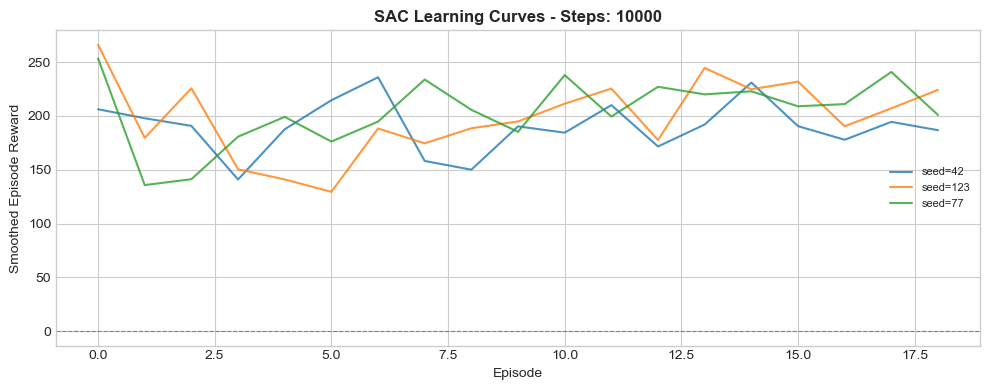

Training selesai.


In [10]:
trained_models  = {}
train_histories = {}

exp_bar = tqdm(ABLATION_CONFIGS.items(), desc='Experiments')
for exp_id, config in exp_bar:
    # Skip static gamma dan ensemble (tidak ada RL training)
    if config.get('static_gamma') is not None or config.get('is_ensemble'):
        continue

    train_histories[exp_id] = {}
    seed_bar = tqdm(SEEDS, desc=f'Seeds for {exp_id}', leave=False)

    for seed in seed_bar:
        name = f'model_{exp_id}_s{seed}'
        if os.path.exists(name + '.zip') and not FORCE_RETRAIN:
            trained_models[(exp_id, seed)] = name
            print(f'  Loaded existing: {name}')
            continue

        # FIX: split='train' (bukan data_start_offset=0)
        env      = AblationPortfolioEnv(ret_train, config, split='train')
        callback = RewardLoggerCallback()
        model    = SAC('MlpPolicy', env, seed=seed, verbose=0, learning_rate=3e-4)
        model.learn(total_timesteps=TRAIN_STEPS, callback=callback, progress_bar=True)

        model.save(name)
        trained_models[(exp_id, seed)]  = name
        train_histories[exp_id][seed]   = callback.episode_rewards

if 'E2_Sharpe' in train_histories:
    plot_learning_curves(train_histories['E2_Sharpe'])

print('Training selesai.')


## 11. Backtesting Loop

In [11]:
results_test  = {}
results_train = {}

all_exp_ids = list(ABLATION_CONFIGS.keys()) + ['Classic-MV']

for exp_id in tqdm(all_exp_ids, desc='Backtesting'):
    results_test[exp_id]  = pd.DataFrame()
    results_train[exp_id] = pd.DataFrame()
    config = ABLATION_CONFIGS.get(exp_id, {})

    for seed in SEEDS:
        model           = None
        ensemble_models = []

        if exp_id != 'Classic-MV' and config.get('static_gamma') is None:
            if config.get('is_ensemble'):
                for m_id in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']:
                    ensemble_models.append(SAC.load(trained_models[(m_id, seed)]))
            else:
                model = SAC.load(trained_models[(exp_id, seed)])

        def get_weights(split, step_idx):
            c = GLOBAL_CACHE[(split, step_idx)]
            if exp_id == 'Classic-MV':
                return compute_classic_mv_weights(c['win'])
            if config.get('static_gamma') is not None:
                return fast_centrality_weights(c['cov_f'], c['cent_vec'],
                                               c['mu'], config['static_gamma'])
            obs, _ = build_observation(c['win'], config, c['nw_feat_full'], c['corr_f'])
            if config.get('is_ensemble'):
                gammas = [float(em.predict(obs, deterministic=True)[0][0])
                          for em in ensemble_models]
                return fast_centrality_weights(c['cov_f'], c['cent_vec'],
                                               c['mu'], np.mean(gammas))
            action, _ = model.predict(obs, deterministic=True)
            return fast_centrality_weights(c['cov_f'], c['cent_vec'],
                                           c['mu'], float(action[0]))

        # --- Testing ---
        rets_test = [
            np.dot(get_weights('test', i), ret_test.iloc[i].values)
            for i in range(SET_WINDOW, len(ret_test))
        ]
        results_test[exp_id][seed] = pd.Series(
            rets_test, index=ret_test.index[SET_WINDOW:])

        # --- Training (evaluasi ulang, bukan training) ---
        rets_train_eval = [
            np.dot(get_weights('train', i), ret_train.iloc[i].values)
            for i in range(SET_WINDOW, len(ret_train))
        ]
        results_train[exp_id][seed] = pd.Series(
            rets_train_eval, index=ret_train.index[SET_WINDOW:])

print('Backtesting selesai.')


Backtesting:   0%|          | 0/9 [00:00<?, ?it/s]

Backtesting selesai.


## 12. Final Analysis, Wilcoxon Tests & SHAP


=== Generating Final Dashboards ===


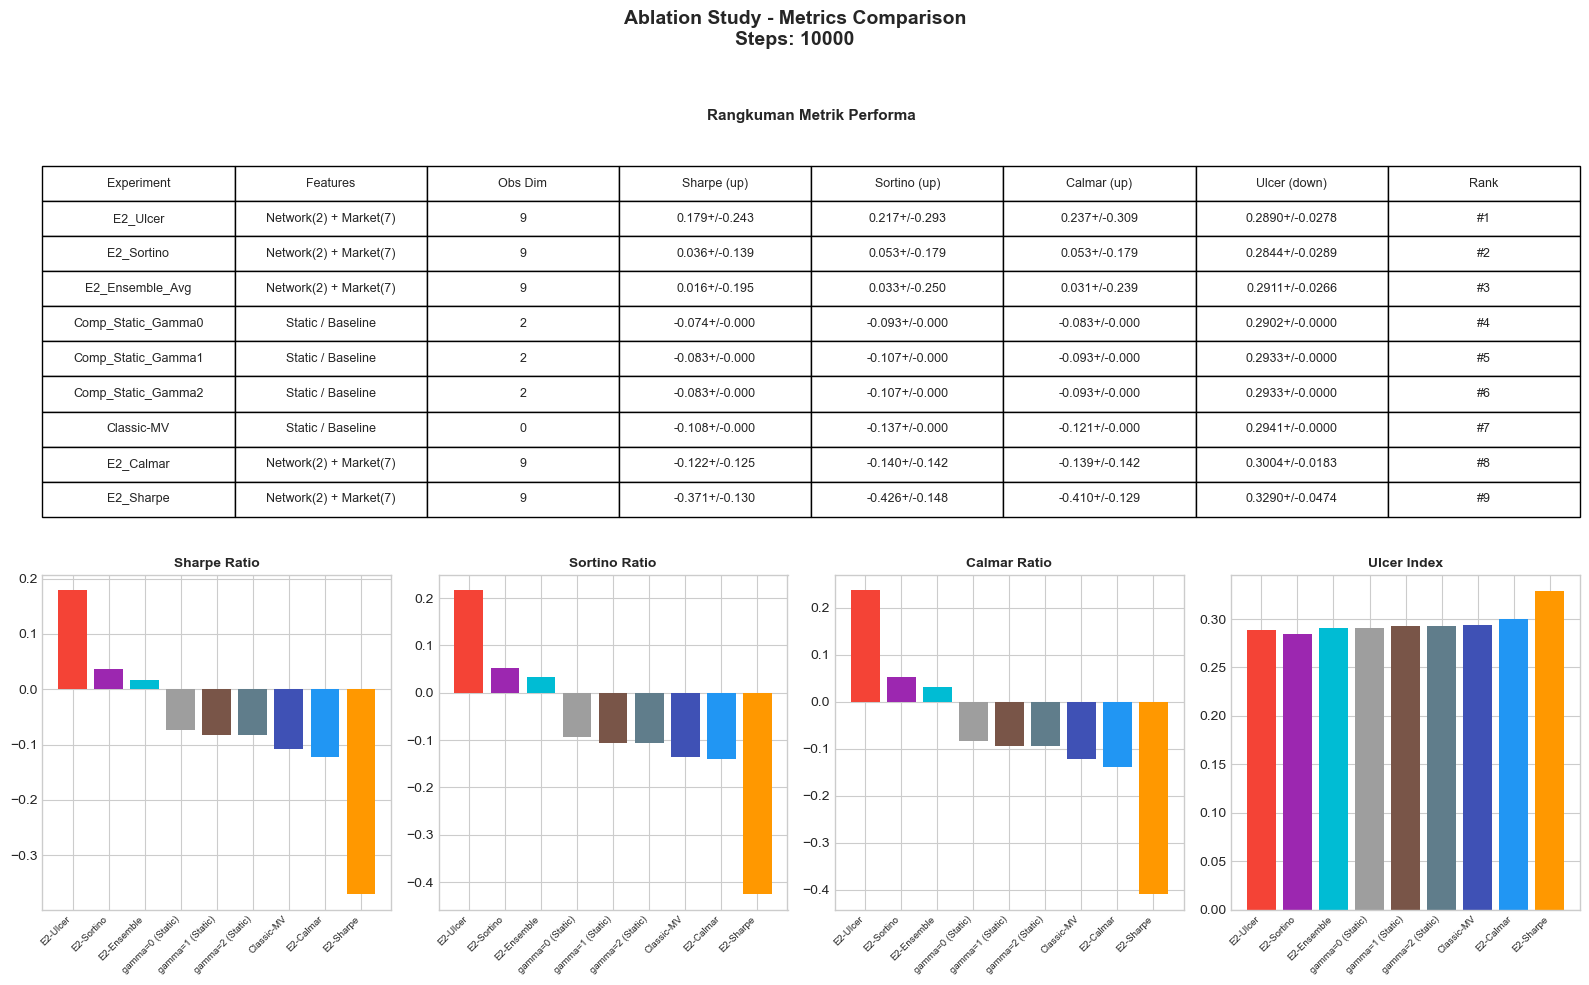

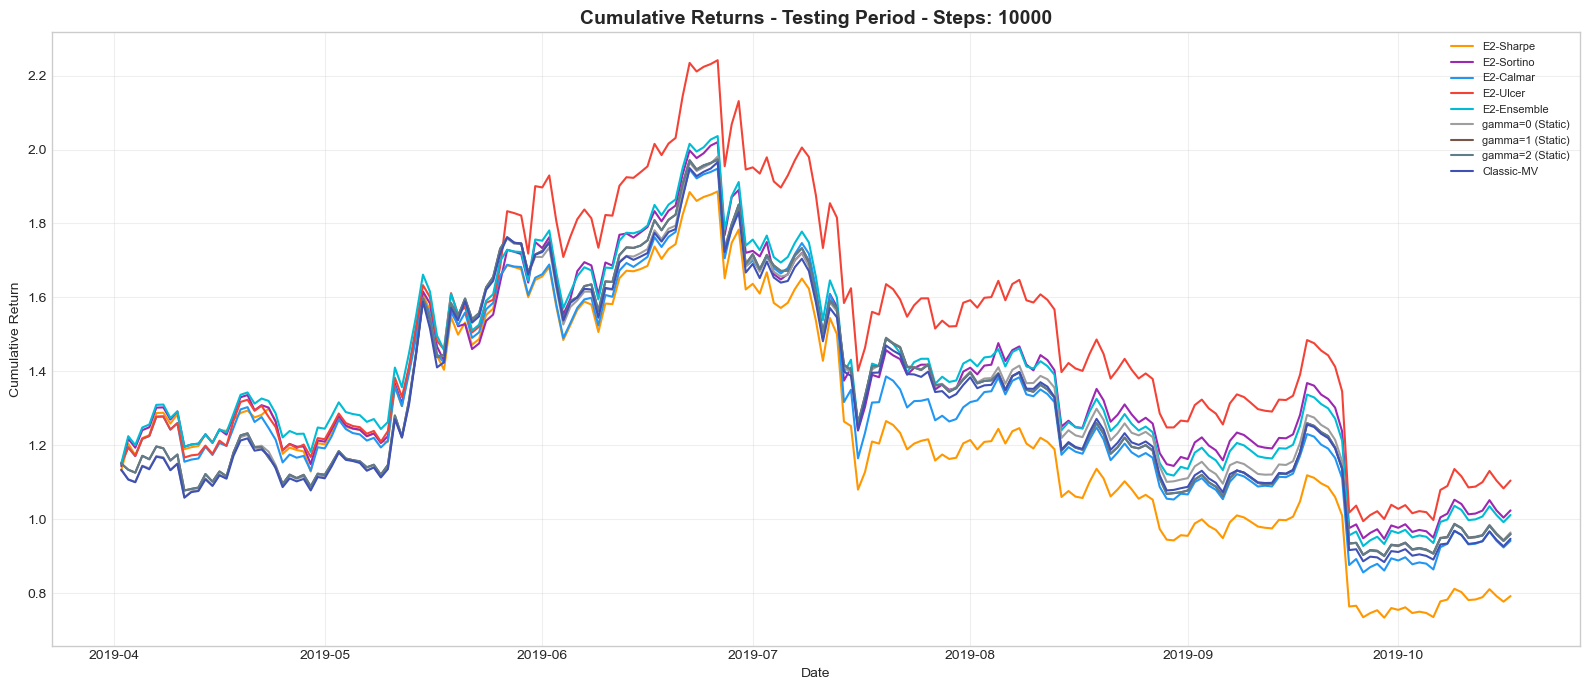

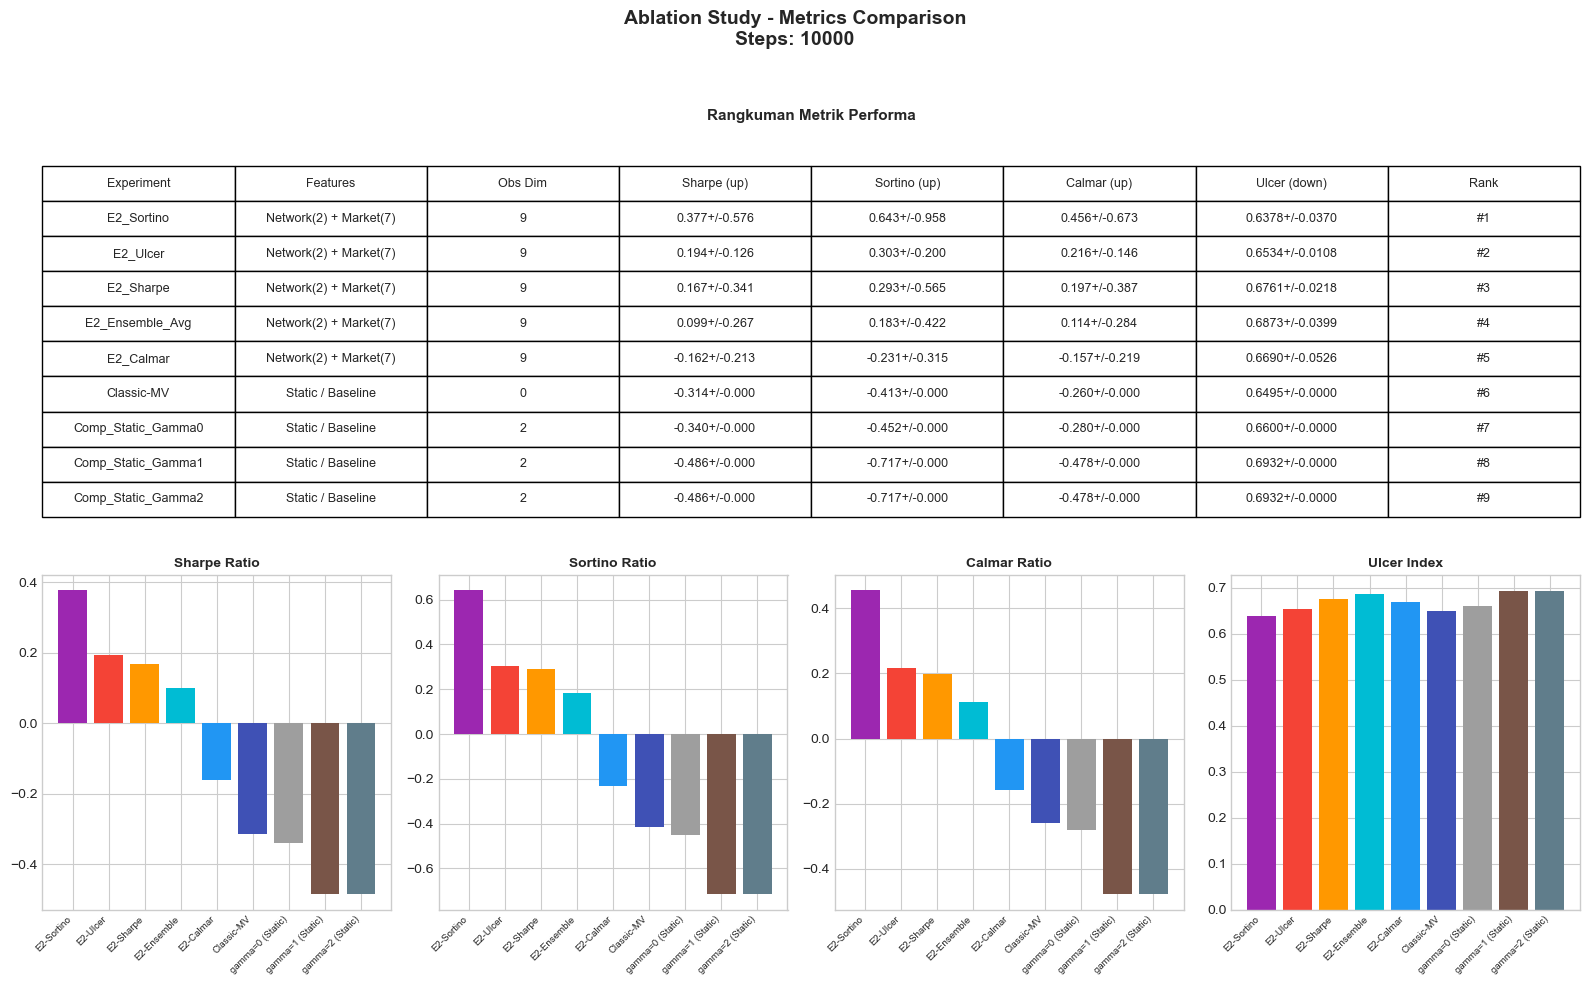

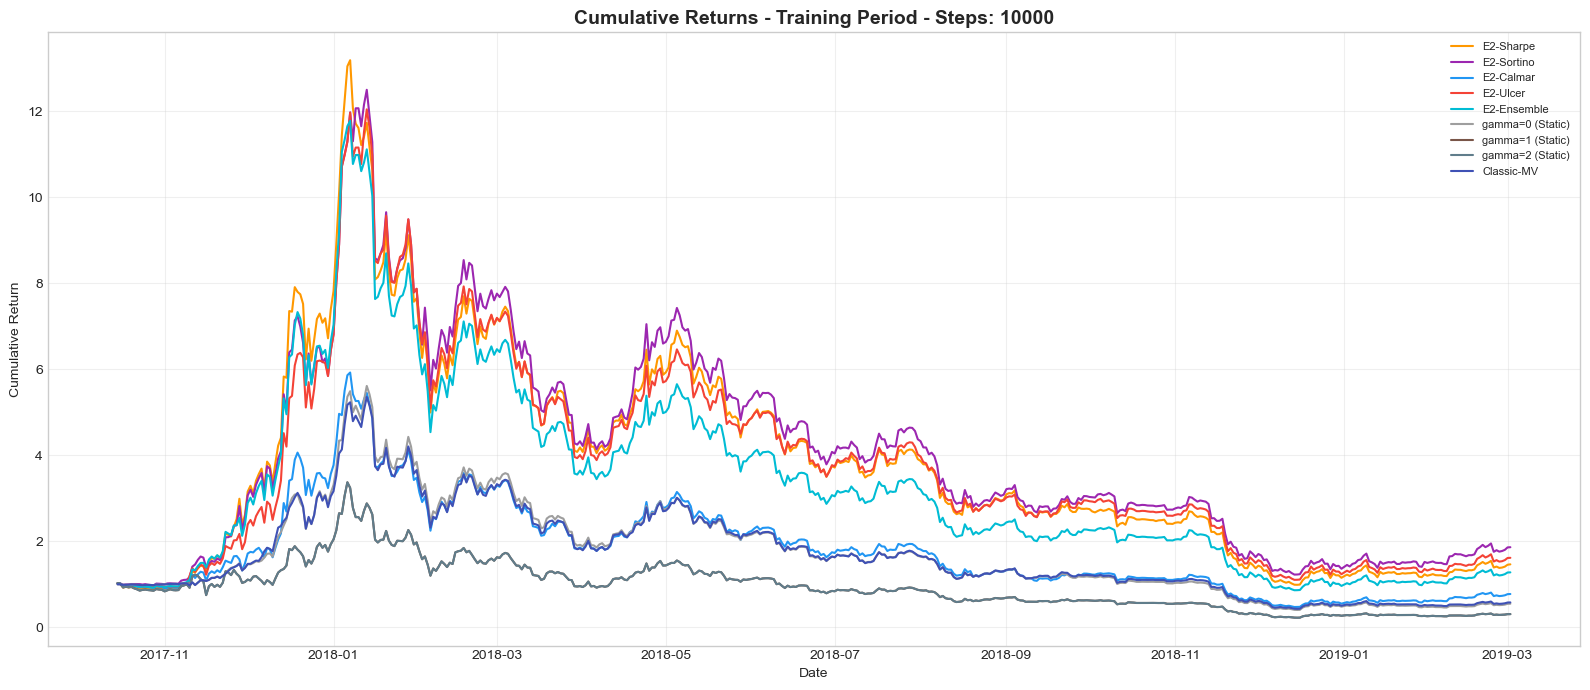


=== Wilcoxon Signed-Rank Tests (vs Classic-MV, Testing Period) ===
  E2_Sharpe             : p = 0.4080 
  E2_Sortino            : p = 0.7353 
  E2_Calmar             : p = 0.7492 
  E2_Ulcer              : p = 0.6519 
  E2_Ensemble_Avg       : p = 0.7651 
  Comp_Static_Gamma0    : p = 0.5515 
  Comp_Static_Gamma1    : p = 0.2601 
  Comp_Static_Gamma2    : p = 0.2601 
  (* = signifikan pada alpha=0.05)

=== Generating SHAP Analysis ===
Generating SHAP analysis for E2_Sharpe...


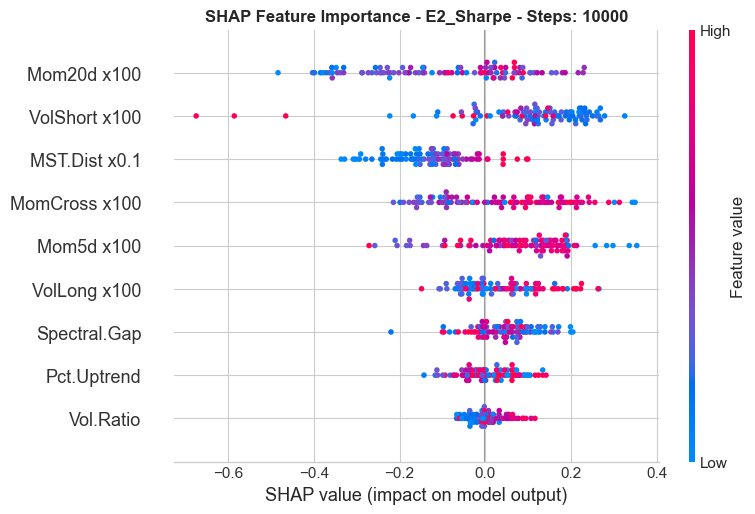

Generating SHAP analysis for E2_Sortino...


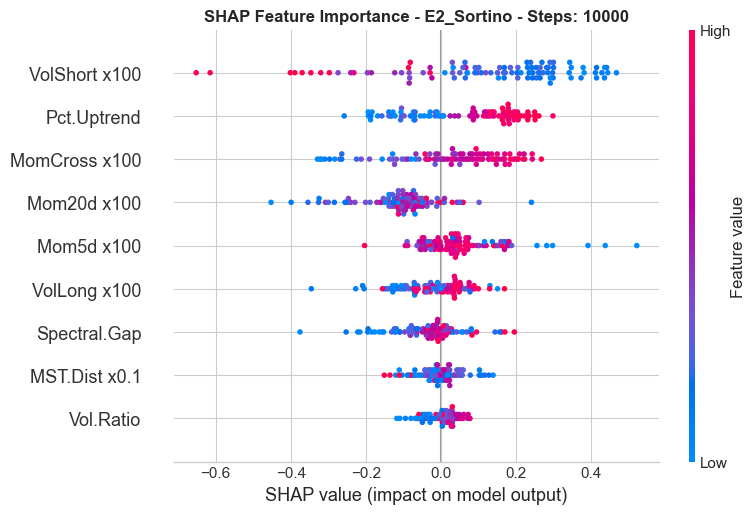

Generating SHAP analysis for E2_Calmar...


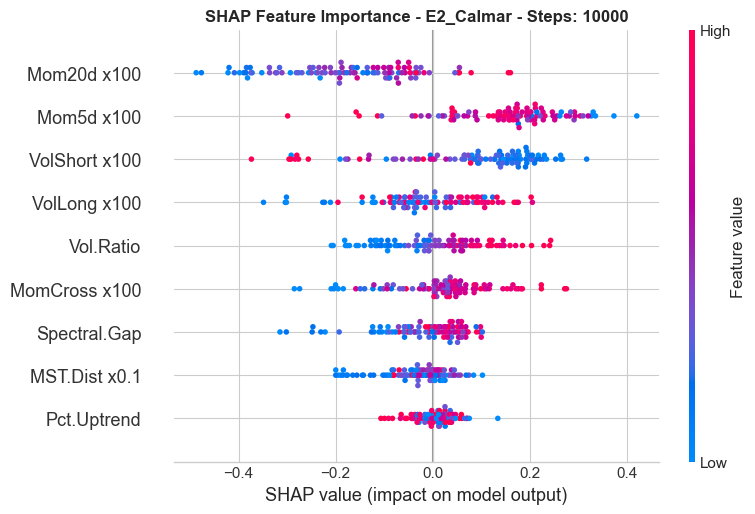

Generating SHAP analysis for E2_Ulcer...


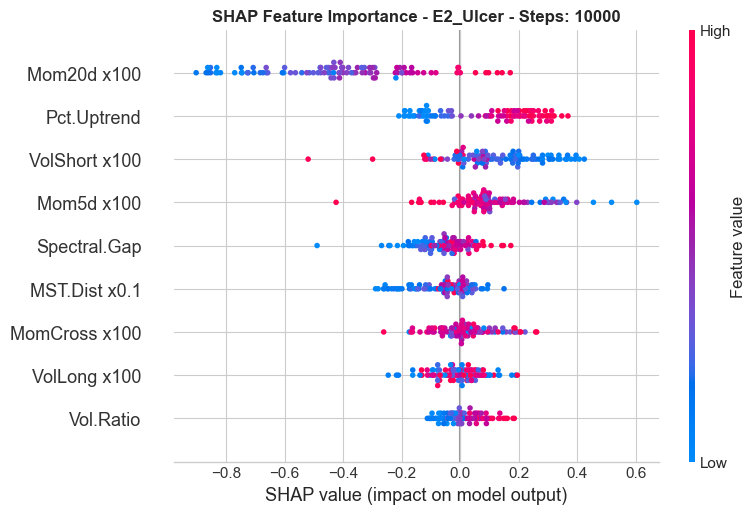

Generating SHAP analysis for E2_Ensemble_Avg...


ExactExplainer explainer: 99it [00:14,  2.06it/s]                        


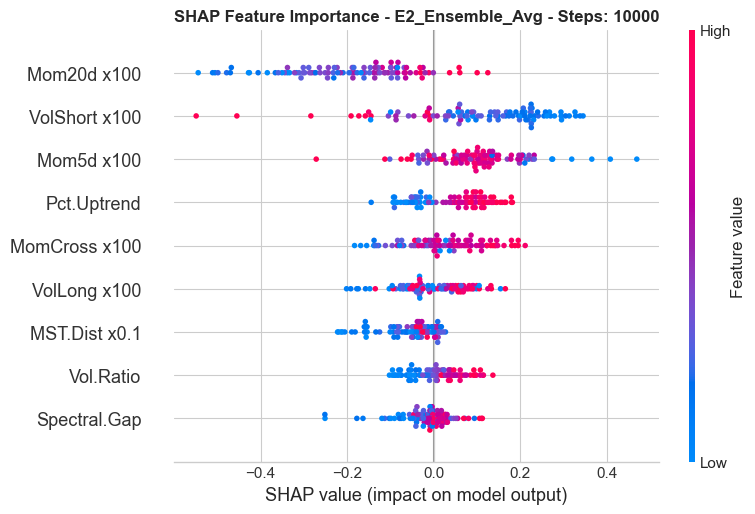


Analisis selesai.


In [12]:
print('\n=== Generating Final Dashboards ===')
generate_dashboard(results_test,  'Ablation Study', 'Testing',  'testing.png')
generate_dashboard(results_train, 'Ablation Study', 'Training', 'training.png')

# FIX: run_wilcoxon_tests sekarang benar-benar dipanggil + hasil ditampilkan
print('\n=== Wilcoxon Signed-Rank Tests (vs Classic-MV, Testing Period) ===')
pvals = run_wilcoxon_tests(results_test, baseline_id='Classic-MV')
for exp_id, p in pvals.items():
    sig = '*' if (not np.isnan(p) and p < STAT_ALPHA) else ''
    pstr = f'{p:.4f}' if not np.isnan(p) else 'NaN'
    print(f'  {exp_id:<22}: p = {pstr} {sig}')
print(f'  (* = signifikan pada alpha={STAT_ALPHA})')

print('\n=== Generating SHAP Analysis ===')
seed0 = SEEDS[0]
for exp_id in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer', 'E2_Ensemble_Avg']:
    config = ABLATION_CONFIGS.get(exp_id, {})
    if exp_id == 'E2_Ensemble_Avg':
        m_paths = [trained_models.get((m, seed0))
                   for m in ['E2_Sharpe', 'E2_Sortino', 'E2_Calmar', 'E2_Ulcer']]
    else:
        m_paths = trained_models.get((exp_id, seed0))
    env_shap = AblationPortfolioEnv(ret_test, config, split='test')
    plot_shap_analysis(m_paths, env_shap, config, exp_id)

print('\nAnalisis selesai.')
